# Cooling Jet Source-Volume Envelope

? notebook ? Fluent ???? CSV ????? `CT = 0.8` ????????????????????????

This notebook extracts the `CT = 0.8` cooling-jet source-volume envelope from Fluent cell-centered CSV data and exports both a colored 3D figure and a four-view diagnostic figure.

## Imports And Configuration / ???????

???????????????????????????????????????? `T_m`?? CSV ??????

This cell imports dependencies and defines all user-facing controls. The mainstream temperature is denoted as `T_m` and is taken as the maximum static temperature in the CSV.

In [1]:
# Purpose: import dependencies and configure the CT=0.8 envelope workflow.
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.interpolate import griddata
from scipy.ndimage import binary_closing, binary_fill_holes, gaussian_filter, gaussian_filter1d, label
from scipy.spatial import cKDTree
from IPython.display import Image, display

WORK_DIR = Path.cwd()
CSV_PATH: Path | None = None
OUTPUT_DIR = WORK_DIR / "jet_envelope_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

CT_LEVEL = 0.80
COLD_PERCENTILE = 2.0

N_X = 74
N_CURVE = 96
SLICE_HALF_WIDTH_X: float | None = None
MIN_POINTS_PER_SLICE = 350
Y_GRID_N = 132
Z_GRID_N = 96
CONTOUR_SMOOTH_SIGMA = 1.1
SURFACE_SMOOTH_SIGMA = (1.15, 1.10)
Y_PAD = 0.10
Z_PAD = 0.08

IDW_NEIGHBORS = 10
IDW_POWER = 2.0
SURFACE_TEMP_SMOOTH_SIGMA = (1.2, 1.0)
COLOR_PERCENTILES = (2, 98)

PLATE_COLOR = "#e8e8e8"
SURFACE_CMAP = "turbo"
DPI = 260
Z_VISUAL_EXAGGERATION = 1.65
VIEW_ELEV = 23
VIEW_AZIM = -56


## Style And Utility Functions / ???????

??????????CSV ??????? 3D ???????????????????????????????

This cell defines plotting style, CSV selection, and 3D axis cleanup helpers. The colored 3D figure removes grid lines while keeping axes and a light-gray wall plane.

In [2]:
# Purpose: define plotting style and reusable utility helpers.
def set_times_style() -> None:
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })


def choose_csv(path: Path | None = None) -> Path:
    if path is not None:
        return Path(path)
    csv_files = sorted(WORK_DIR.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {WORK_DIR}")
    return max(csv_files, key=lambda p: p.stat().st_size)


def largest_component(mask: np.ndarray) -> np.ndarray:
    labels, n_labels = label(mask)
    if n_labels == 0:
        return mask
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0
    return labels == int(sizes.argmax())


def remove_3d_grid(ax: Any) -> None:
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
        axis.pane.set_edgecolor((0.82, 0.82, 0.82, 1.0))
        axis._axinfo["grid"]["linewidth"] = 0.0


def add_light_plate(ax: Any, xlim: tuple[float, float], ylim: tuple[float, float]) -> None:
    xx, yy = np.meshgrid(xlim, ylim)
    zz = np.zeros_like(xx)
    ax.plot_surface(xx, yy, zz, color=PLATE_COLOR, alpha=0.18, linewidth=0, shade=False, antialiased=True)


## Data Loading And Normalization / ?????????

????? CSV??? `x/D` ? `z/D` ?????????????? `CT = (T_m - T)/(T_m - T_c)`??? `T_m` ? CSV ?????`T_c` ???????

This cell loads the CSV, resets the `x/D` and `z/D` origins, and computes `CT = (T_m - T)/(T_m - T_c)`. Here `T_m` is the maximum static temperature in the CSV and `T_c` is a cold-temperature percentile.

In [3]:
# Purpose: load CFD cell data and compute CT using T_m from the CSV maximum temperature.
def load_cfd_csv(path: Path) -> tuple[pd.DataFrame, dict[str, float]]:
    df = pd.read_csv(path, usecols=["xD", "yD", "zD", "static_temperature"])
    df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    df["xD"] = df["xD"] - float(df["xD"].min())
    df["zD"] = df["zD"] - float(df["zD"].min())

    temperature = df["static_temperature"].to_numpy(float)
    t_c = float(np.percentile(temperature, COLD_PERCENTILE))
    t_m = float(temperature.max())
    df["CT"] = np.clip((t_m - temperature) / max(t_m - t_c, 1e-12), 0.0, 1.0)
    df["T_over_Tm"] = temperature / t_m

    refs = {"T_c": t_c, "T_m": t_m}
    return df, refs


def summarize_input(df: pd.DataFrame, refs: dict[str, float], csv_path: Path) -> pd.DataFrame:
    return pd.DataFrame([{
        "csv": csv_path.name,
        "rows": len(df),
        "T_c [K]": refs["T_c"],
        "T_m [K]": refs["T_m"],
        "CT level": CT_LEVEL,
        "x/D min": df["xD"].min(),
        "x/D max": df["xD"].max(),
        "y/D min": df["yD"].min(),
        "y/D max": df["yD"].max(),
        "z/D min": df["zD"].min(),
        "z/D max": df["zD"].max(),
    }])


## Envelope Dataset Construction / ???????

?????? `x/D` ??? `CT = 0.8` ????????????? `x/D` ??????????????????????????????????dataset? ???????????????

This cell extracts the `CT = 0.8` region in each `x/D` slice as a closed boundary and connects the slices into one envelope surface. No machine-learning model, training, or testing is used; the dataset here is the rendered envelope vertices and faces.

In [4]:
# Purpose: extract the CT isocontour envelope and assemble surface vertices/faces.
def interpolate_missing_rows(arr: np.ndarray, x: np.ndarray) -> np.ndarray:
    out = np.asarray(arr, dtype=float).copy()
    for j in range(out.shape[1]):
        good = np.isfinite(out[:, j])
        if good.sum() < 2:
            raise ValueError("Too few valid CT contours to interpolate the envelope.")
        out[:, j] = np.interp(x, x[good], out[good, j])
    return out


def extract_ct_envelope(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_stations = np.linspace(0.0, float(df["xD"].max()), N_X)
    dx = x_stations[1] - x_stations[0]
    half_dx = 0.5 * dx if SLICE_HALF_WIDTH_X is None else SLICE_HALF_WIDTH_X

    cold = df[df["CT"] >= CT_LEVEL]
    y_grid = np.linspace(float(cold["yD"].quantile(0.003)) - Y_PAD, float(cold["yD"].quantile(0.997)) + Y_PAD, Y_GRID_N)
    z_grid = np.linspace(0.0, float(cold["zD"].quantile(0.997)) + Z_PAD, Z_GRID_N)
    yy, zz = np.meshgrid(y_grid, z_grid, indexing="ij")

    curves_y = np.full((N_X, N_CURVE), np.nan)
    curves_z = np.full((N_X, N_CURVE), np.nan)
    valid_counts = np.zeros(N_X, dtype=int)

    for i, x0 in enumerate(x_stations):
        sl = df[(df["xD"] >= x0 - half_dx) & (df["xD"] <= x0 + half_dx)]
        sl = sl[(sl["yD"] >= y_grid.min()) & (sl["yD"] <= y_grid.max()) & (sl["zD"] <= z_grid.max())]
        valid_counts[i] = len(sl)
        if len(sl) < MIN_POINTS_PER_SLICE:
            continue

        points = sl[["yD", "zD"]].to_numpy(float)
        values = sl["CT"].to_numpy(float)
        ct_linear = griddata(points, values, (yy, zz), method="linear")
        ct_nearest = griddata(points, values, (yy, zz), method="nearest")
        ct_grid = np.where(np.isfinite(ct_linear), ct_linear, ct_nearest)
        ct_grid = gaussian_filter(ct_grid, sigma=CONTOUR_SMOOTH_SIGMA, mode="nearest")

        inside = ct_grid >= CT_LEVEL
        inside = binary_fill_holes(binary_closing(inside, iterations=1))
        inside = largest_component(inside)
        has_inside = inside.any(axis=1)
        if has_inside.sum() < 4:
            continue

        y_inside = y_grid[has_inside]
        top_idx = np.array([np.where(inside[k])[0].max() for k in np.where(has_inside)[0]])
        z_top = z_grid[top_idx]

        y_curve = np.r_[y_inside[0], y_inside, y_inside[-1]]
        z_curve = np.r_[0.0, z_top, 0.0]
        s_old = np.linspace(0.0, 1.0, len(y_curve))
        s_new = np.linspace(0.0, 1.0, N_CURVE)
        curves_y[i] = np.interp(s_new, s_old, y_curve)
        curves_z[i] = np.interp(s_new, s_old, z_curve)

    curves_y = gaussian_filter(interpolate_missing_rows(curves_y, x_stations), sigma=SURFACE_SMOOTH_SIGMA, mode="nearest")
    curves_z = gaussian_filter(interpolate_missing_rows(curves_z, x_stations), sigma=SURFACE_SMOOTH_SIGMA, mode="nearest")
    curves_z[:, 0] = 0.0
    curves_z[:, -1] = 0.0
    curves_z = np.maximum(curves_z, 0.0)
    x = np.repeat(x_stations[:, None], N_CURVE, axis=1)
    return x, curves_y, curves_z, valid_counts


def make_vertices_and_faces(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> tuple[np.ndarray, list[list[int]]]:
    verts = np.column_stack([x.ravel(), y.ravel(), z.ravel()])
    verts = np.vstack([verts, [x[0, 0], 0.5 * (y[0, 0] + y[0, -1]), 0.0], [x[-1, 0], 0.5 * (y[-1, 0] + y[-1, -1]), 0.0]])

    faces: list[list[int]] = []
    for i in range(N_X - 1):
        for j in range(N_CURVE - 1):
            a = i * N_CURVE + j
            faces.append([a, a + N_CURVE, a + N_CURVE + 1, a + 1])

    inlet_center = N_X * N_CURVE
    outlet_center = inlet_center + 1
    for j in range(N_CURVE - 1):
        faces.append([inlet_center, j, j + 1])
        base = (N_X - 1) * N_CURVE
        faces.append([outlet_center, base + j, base + j + 1])
    return verts, faces


## Surface Temperature Mapping / ??????

??????????????????????????? `T/T_m`??????????

This cell interpolates raw cell temperatures onto the envelope surface and converts them into dimensionless temperature `T/T_m` for the colored figure.

In [5]:
# Purpose: interpolate surface temperature and convert it to T/T_m.
def idw_surface_temperature_ratio(points: np.ndarray, df: pd.DataFrame, t_m: float) -> np.ndarray:
    data_xyz = df[["xD", "yD", "zD"]].to_numpy(float)
    data_temp = df["static_temperature"].to_numpy(float)
    tree = cKDTree(data_xyz)
    dist, idx = tree.query(points, k=IDW_NEIGHBORS)
    dist = np.asarray(dist, dtype=float)
    idx = np.asarray(idx)

    exact = dist[:, 0] < 1e-12
    weights = 1.0 / np.maximum(dist, 1e-12) ** IDW_POWER
    surface_temp = (weights * data_temp[idx]).sum(axis=1) / weights.sum(axis=1)
    if exact.any():
        surface_temp[exact] = data_temp[idx[exact, 0]]

    ratio = surface_temp / t_m
    regular = ratio[:N_X * N_CURVE].reshape(N_X, N_CURVE)
    ratio[:N_X * N_CURVE] = gaussian_filter(regular, sigma=SURFACE_TEMP_SMOOTH_SIGMA, mode="nearest").ravel()
    return ratio


## Plotting Functions / ????

????????????????????????????????????? `T/T_m`?????????????????????? `z/D` ? `y/D`?

This cell defines the colored 3D figure, four-view diagnostic figure, and compact diagnostics. The 3D colored figure has no grid lines; the colorbar is horizontal `T/T_m`; the lower-left 3D panel is enlarged and axis labels are corrected.

In [6]:
# Purpose: define plotting functions for final figures and diagnostics.
def set_3d_axes(ax: Any, xlim: tuple[float, float], ylim: tuple[float, float], zlim: tuple[float, float], *, grid: bool) -> None:
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)
    ax.set_xlabel(r"$x/D$", labelpad=7)
    ax.set_ylabel(r"$y/D$", labelpad=7)
    ax.set_zlabel(r"$z/D$", labelpad=5)
    ax.set_box_aspect((xlim[1] - xlim[0], ylim[1] - ylim[0], (zlim[1] - zlim[0]) * Z_VISUAL_EXAGGERATION))
    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
    if grid:
        ax.grid(True, alpha=0.18)
    else:
        remove_3d_grid(ax)


def face_colors_from_ratio(faces: list[list[int]], ratio: np.ndarray) -> tuple[np.ndarray, colors.Normalize, Any]:
    face_values = np.array([np.mean(ratio[f]) for f in faces])
    vmin, vmax = np.percentile(face_values, COLOR_PERCENTILES)
    norm = colors.Normalize(vmin=float(vmin), vmax=float(vmax))
    cmap = plt.get_cmap(SURFACE_CMAP)
    facecolors = cmap(norm(face_values))
    facecolors[:, 3] = 0.96
    return facecolors, norm, cmap


def plot_main_envelope(x: np.ndarray, y: np.ndarray, z: np.ndarray, verts: np.ndarray, faces: list[list[int]], ratio: np.ndarray) -> Path:
    set_times_style()
    ratio_grid = ratio[:N_X * N_CURVE].reshape(N_X, N_CURVE)
    vmin, vmax = np.percentile(ratio_grid, COLOR_PERCENTILES)
    norm = colors.Normalize(vmin=float(vmin), vmax=float(vmax))
    cmap = plt.get_cmap(SURFACE_CMAP)
    facecolors = cmap(norm(ratio_grid))
    facecolors[..., 3] = 0.96

    xlim = (0.0, float(x.max()))
    ylim = (float(y.min() - 0.08), float(y.max() + 0.08))
    zlim = (0.0, float(z.max() + 0.10))

    fig = plt.figure(figsize=(9.0, 6.2), dpi=DPI)
    ax = fig.add_subplot(111, projection="3d")
    add_light_plate(ax, xlim, ylim)
    ax.plot_surface(
        x,
        y,
        z,
        facecolors=facecolors,
        linewidth=0,
        antialiased=False,
        shade=False,
        alpha=0.96,
    )
    set_3d_axes(ax, xlim, ylim, zlim, grid=False)
    ax.set_title(rf"Cooling jet envelope, $CT={CT_LEVEL:.2f}$", pad=12)

    scalar_map = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    scalar_map.set_array([])
    colorbar = fig.colorbar(scalar_map, ax=ax, orientation="horizontal", shrink=0.58, pad=0.08, fraction=0.045, aspect=32)
    colorbar.set_label(r"$T/T_m$", labelpad=6)
    colorbar.outline.set_linewidth(0.55)

    out = OUTPUT_DIR / f"ct_envelope_{CT_LEVEL:.2f}_3d.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return out

def plot_reference_views(x: np.ndarray, y: np.ndarray, z: np.ndarray, verts: np.ndarray, faces: list[list[int]]) -> Path:
    set_times_style()
    x_axis = x[:, 0]
    y_left = y[:, 0]
    y_right = y[:, -1]
    z_top = z.max(axis=1)

    fig = plt.figure(figsize=(8.8, 7.4), dpi=DPI)
    gs = fig.add_gridspec(2, 2, width_ratios=[1.18, 1.0], height_ratios=[1.0, 1.24], wspace=0.30, hspace=0.34)

    ax1 = fig.add_subplot(gs[0, 0])
    y_bins = np.linspace(y.min(), y.max(), 180)
    z_env = np.zeros_like(y_bins)
    for yi, zi in zip(y.ravel(), z.ravel()):
        k = np.searchsorted(y_bins, yi)
        if 0 <= k < len(z_env):
            z_env[k] = max(z_env[k], zi)
    z_env = gaussian_filter1d(z_env, sigma=2.0, mode="nearest")
    ax1.fill_between(y_bins, 0, z_env, color="0.62", alpha=0.42, edgecolor="0.16", linewidth=0.8)
    ax1.set_xlabel(r"$y/D$")
    ax1.set_ylabel(r"$z/D$")
    ax1.set_xlim(y.min() - 0.08, y.max() + 0.08)
    ax1.set_ylim(0, z.max() + 0.10)
    ax1.grid(True, color="0.78", lw=0.55)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.fill_between(x_axis, 0, z_top, color="0.62", alpha=0.42, edgecolor="0.16", linewidth=0.8)
    ax2.set_xlabel(r"$x/D$")
    ax2.set_ylabel(r"$z/D$")
    ax2.set_xlim(0, x_axis.max())
    ax2.set_ylim(0, z.max() + 0.10)
    ax2.grid(True, color="0.78", lw=0.55)

    ax3 = fig.add_subplot(gs[1, 0], projection="3d")
    ax3.plot_surface(x, y, z, color="0.62", alpha=0.42, linewidth=0, antialiased=False, shade=False)
    add_light_plate(ax3, (0, x_axis.max()), (y.min() - 0.08, y.max() + 0.08))
    set_3d_axes(ax3, (0, x_axis.max()), (y.min() - 0.08, y.max() + 0.08), (0, z.max() + 0.10), grid=False)
    ax3.set_ylabel(r"$y/D$", labelpad=9)
    ax3.set_zlabel(r"$z/D$", labelpad=9)
    ax3.text2D(0.03, 0.58, r"$z/D$", transform=ax3.transAxes, rotation=90, va="center", ha="center")

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.fill_between(x_axis, y_left, y_right, color="0.62", alpha=0.42, edgecolor="0.16", linewidth=0.8)
    ax4.set_xlabel(r"$x/D$")
    ax4.set_ylabel(r"$y/D$")
    ax4.set_xlim(0, x_axis.max())
    ax4.set_ylim(y.min() - 0.08, y.max() + 0.08)
    ax4.grid(True, color="0.78", lw=0.55)

    fig.suptitle(rf"Source-volume envelope check, $CT={CT_LEVEL:.2f}$", y=0.975, fontsize=13)
    out = OUTPUT_DIR / f"ct_envelope_{CT_LEVEL:.2f}_views.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return out

def plot_diagnostics(df: pd.DataFrame, x: np.ndarray, y: np.ndarray, z: np.ndarray) -> Path:
    set_times_style()
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0), dpi=DPI)
    axes[0].hist(df["CT"], bins=60, color="0.35", alpha=0.75)
    axes[0].axvline(CT_LEVEL, color="crimson", lw=1.1)
    axes[0].set_xlabel("CT")
    axes[0].set_ylabel("Cell count")

    axes[1].plot(x[:, 0], z.max(axis=1), color="0.15", lw=1.1)
    axes[1].fill_between(x[:, 0], 0, z.max(axis=1), color="0.65", alpha=0.35)
    axes[1].set_xlabel(r"$x/D$")
    axes[1].set_ylabel(r"$z/D$")

    axes[2].plot(x[:, 0], y[:, 0], color="0.15", lw=1.0)
    axes[2].plot(x[:, 0], y[:, -1], color="0.15", lw=1.0)
    axes[2].fill_between(x[:, 0], y[:, 0], y[:, -1], color="0.65", alpha=0.35)
    axes[2].set_xlabel(r"$x/D$")
    axes[2].set_ylabel(r"$y/D$")
    for ax in axes:
        ax.grid(True, color="0.84", lw=0.5)
    fig.tight_layout()
    out = OUTPUT_DIR / f"ct_envelope_{CT_LEVEL:.2f}_diagnostics.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return out


## Run Workflow And Save Outputs / ?????????

??????????????????????????????????????????? notebook ????????

This cell runs the full workflow top-to-bottom, showing concise status, preview rows, summary tables, diagnostics, and final figures. The notebook is rerunnable without manual changes.

Loading data from local_cell_data_G1C1.csv ...


Building CT=0.8 source-volume envelope ...


Rendering figures ...


Preview rows:


,xD,yD,zD,static_temperature,CT,T_over_Tm
0,0.0,0.33400,0.792997,499.0,0.146825,0.930970
1,0.0,-1.60000,0.571997,497.0,0.154762,0.927239
2,0.0,0.00612,0.191997,511.0,0.099206,0.953358
3,0.0,0.65900,1.189997,497.0,0.154762,0.927239
4,0.0,0.60700,0.738997,498.0,0.150794,0.929104


Summary:


,value
csv,local_cell_data_G1C1.csv
rows,316860
T_c [K],284.0
T_m [K],536.0
CT level,0.8
x/D min,0.0
x/D max,2.0
y/D min,-2.0
y/D max,2.0
z/D min,0.0


Diagnostics: C:\Users\11528\Desktop\paper_2\database\G1\jet_envelope_outputs\ct_envelope_0.80_diagnostics.png


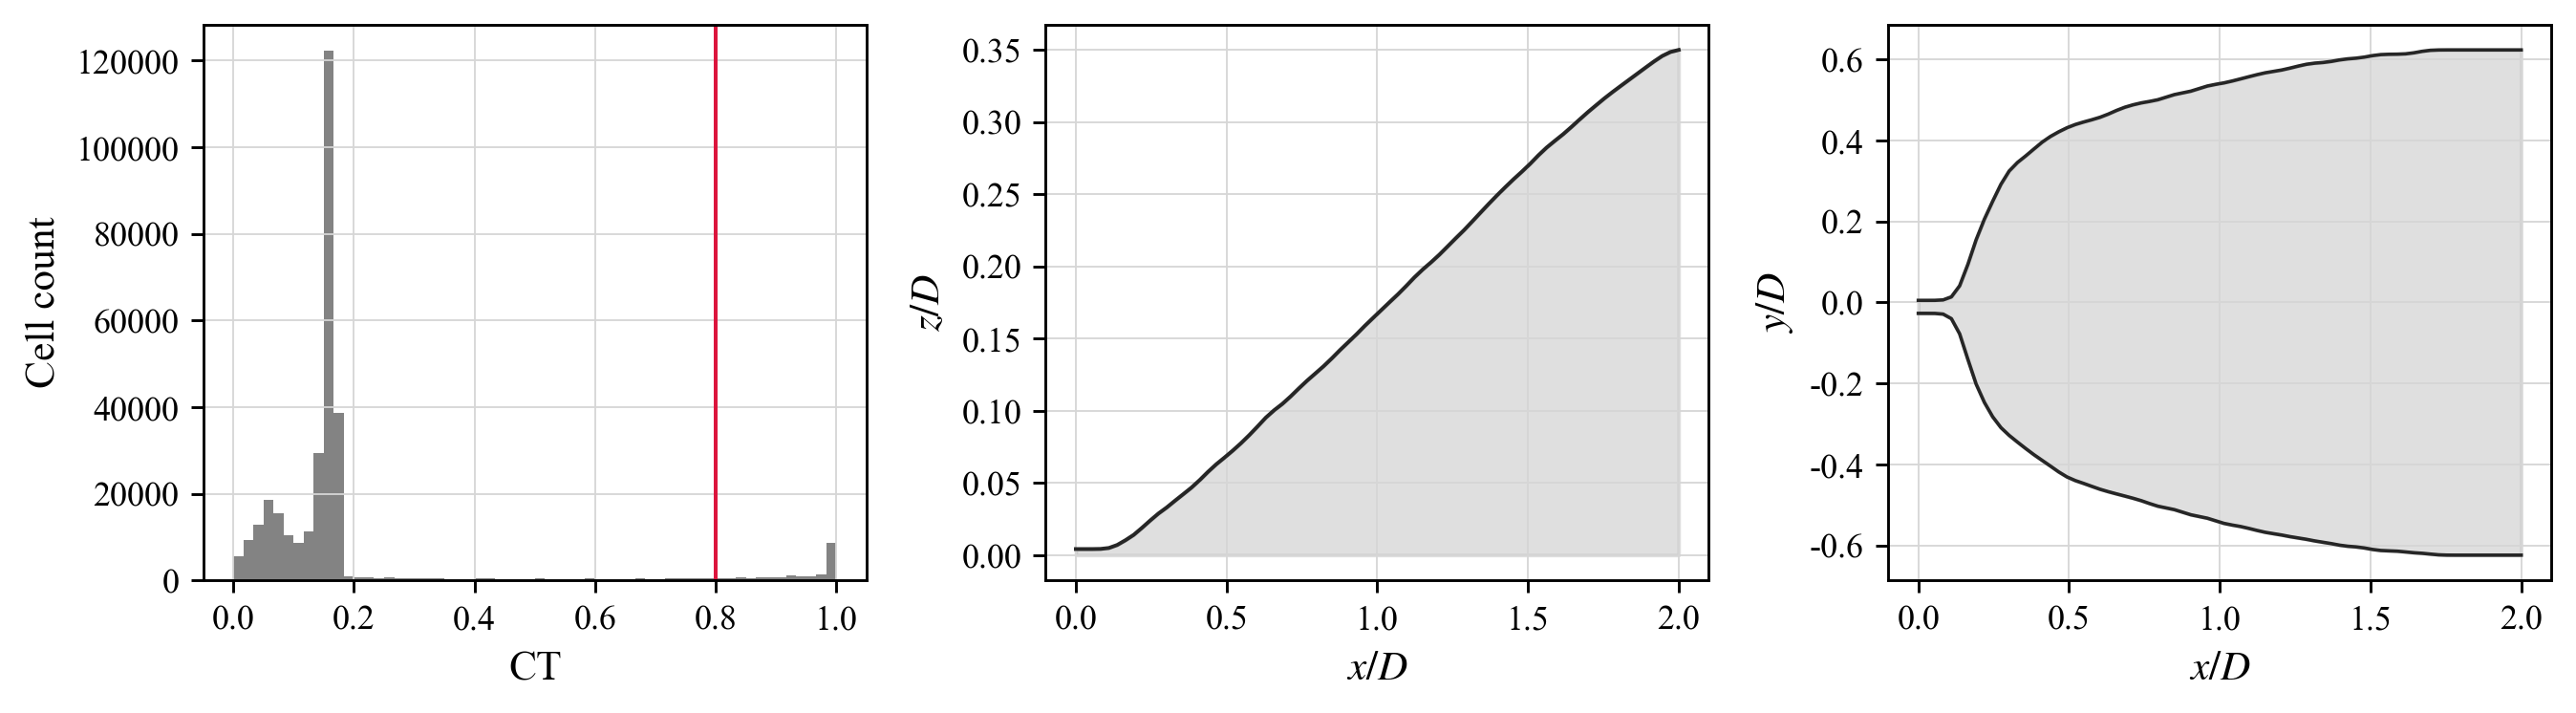

3D envelope: C:\Users\11528\Desktop\paper_2\database\G1\jet_envelope_outputs\ct_envelope_0.80_3d.png


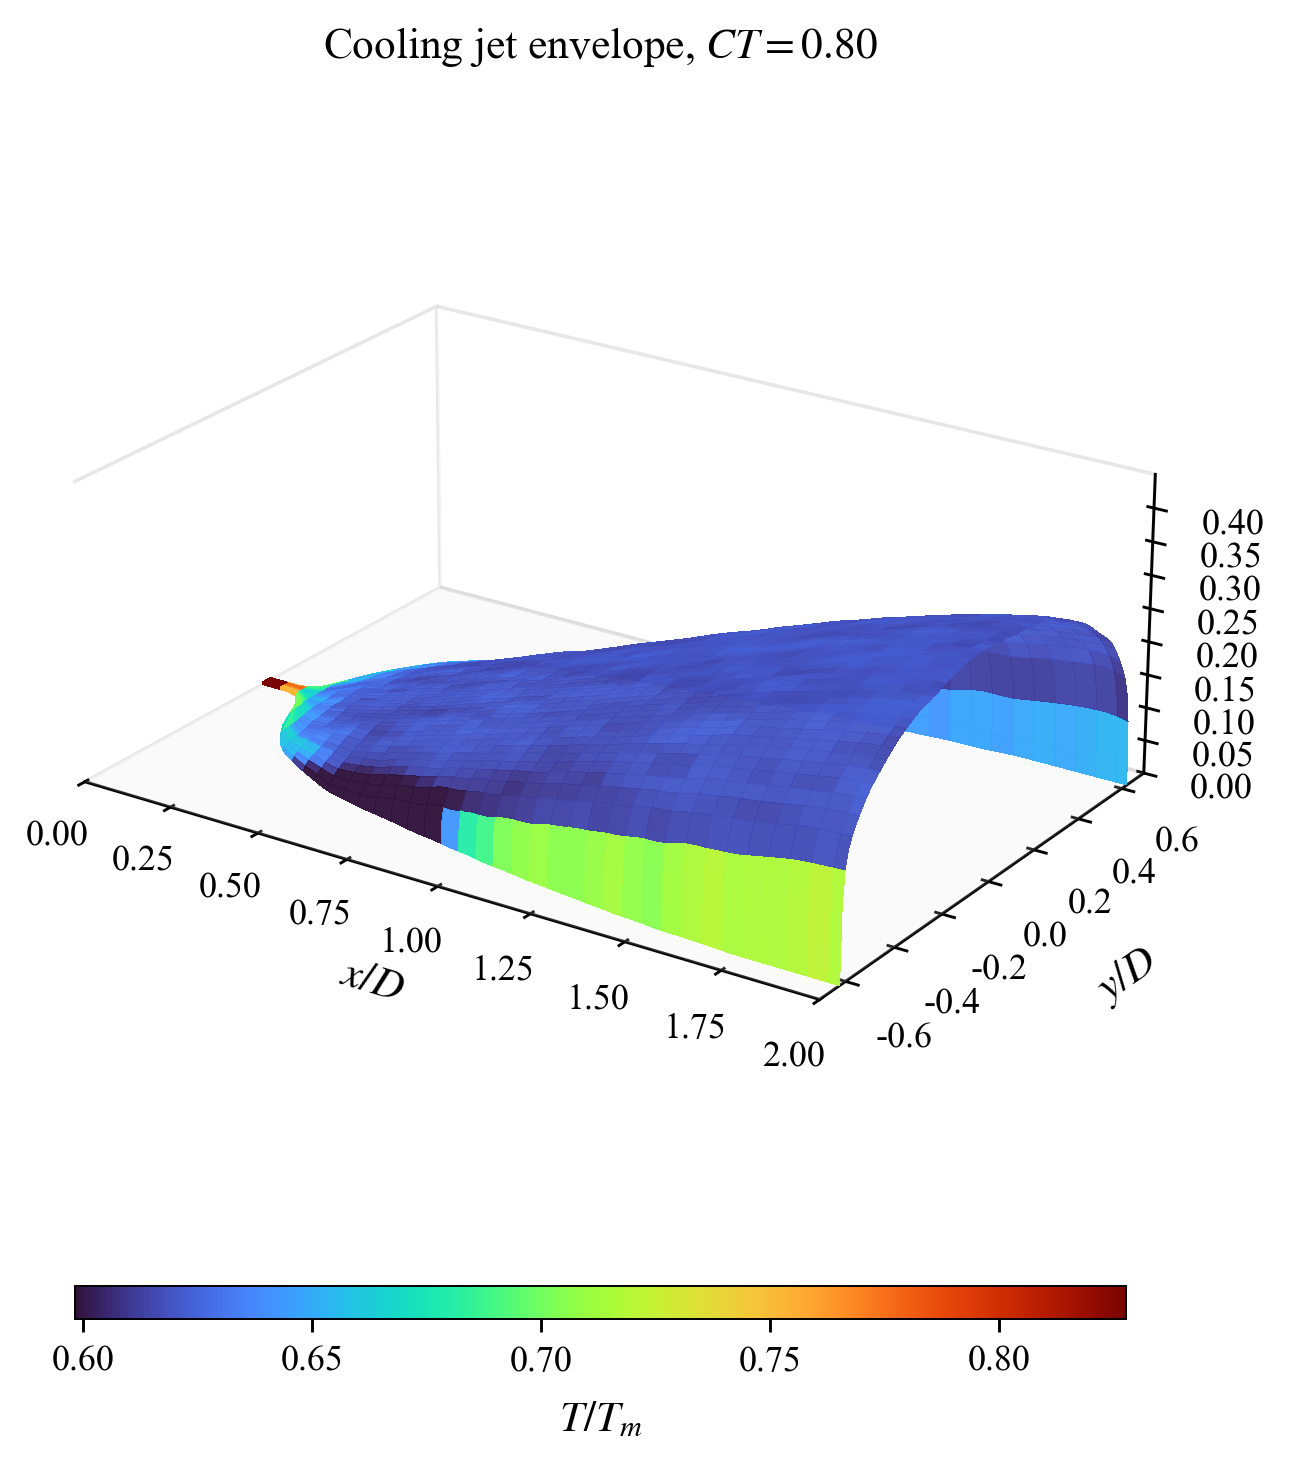

Four-view check: C:\Users\11528\Desktop\paper_2\database\G1\jet_envelope_outputs\ct_envelope_0.80_views.png


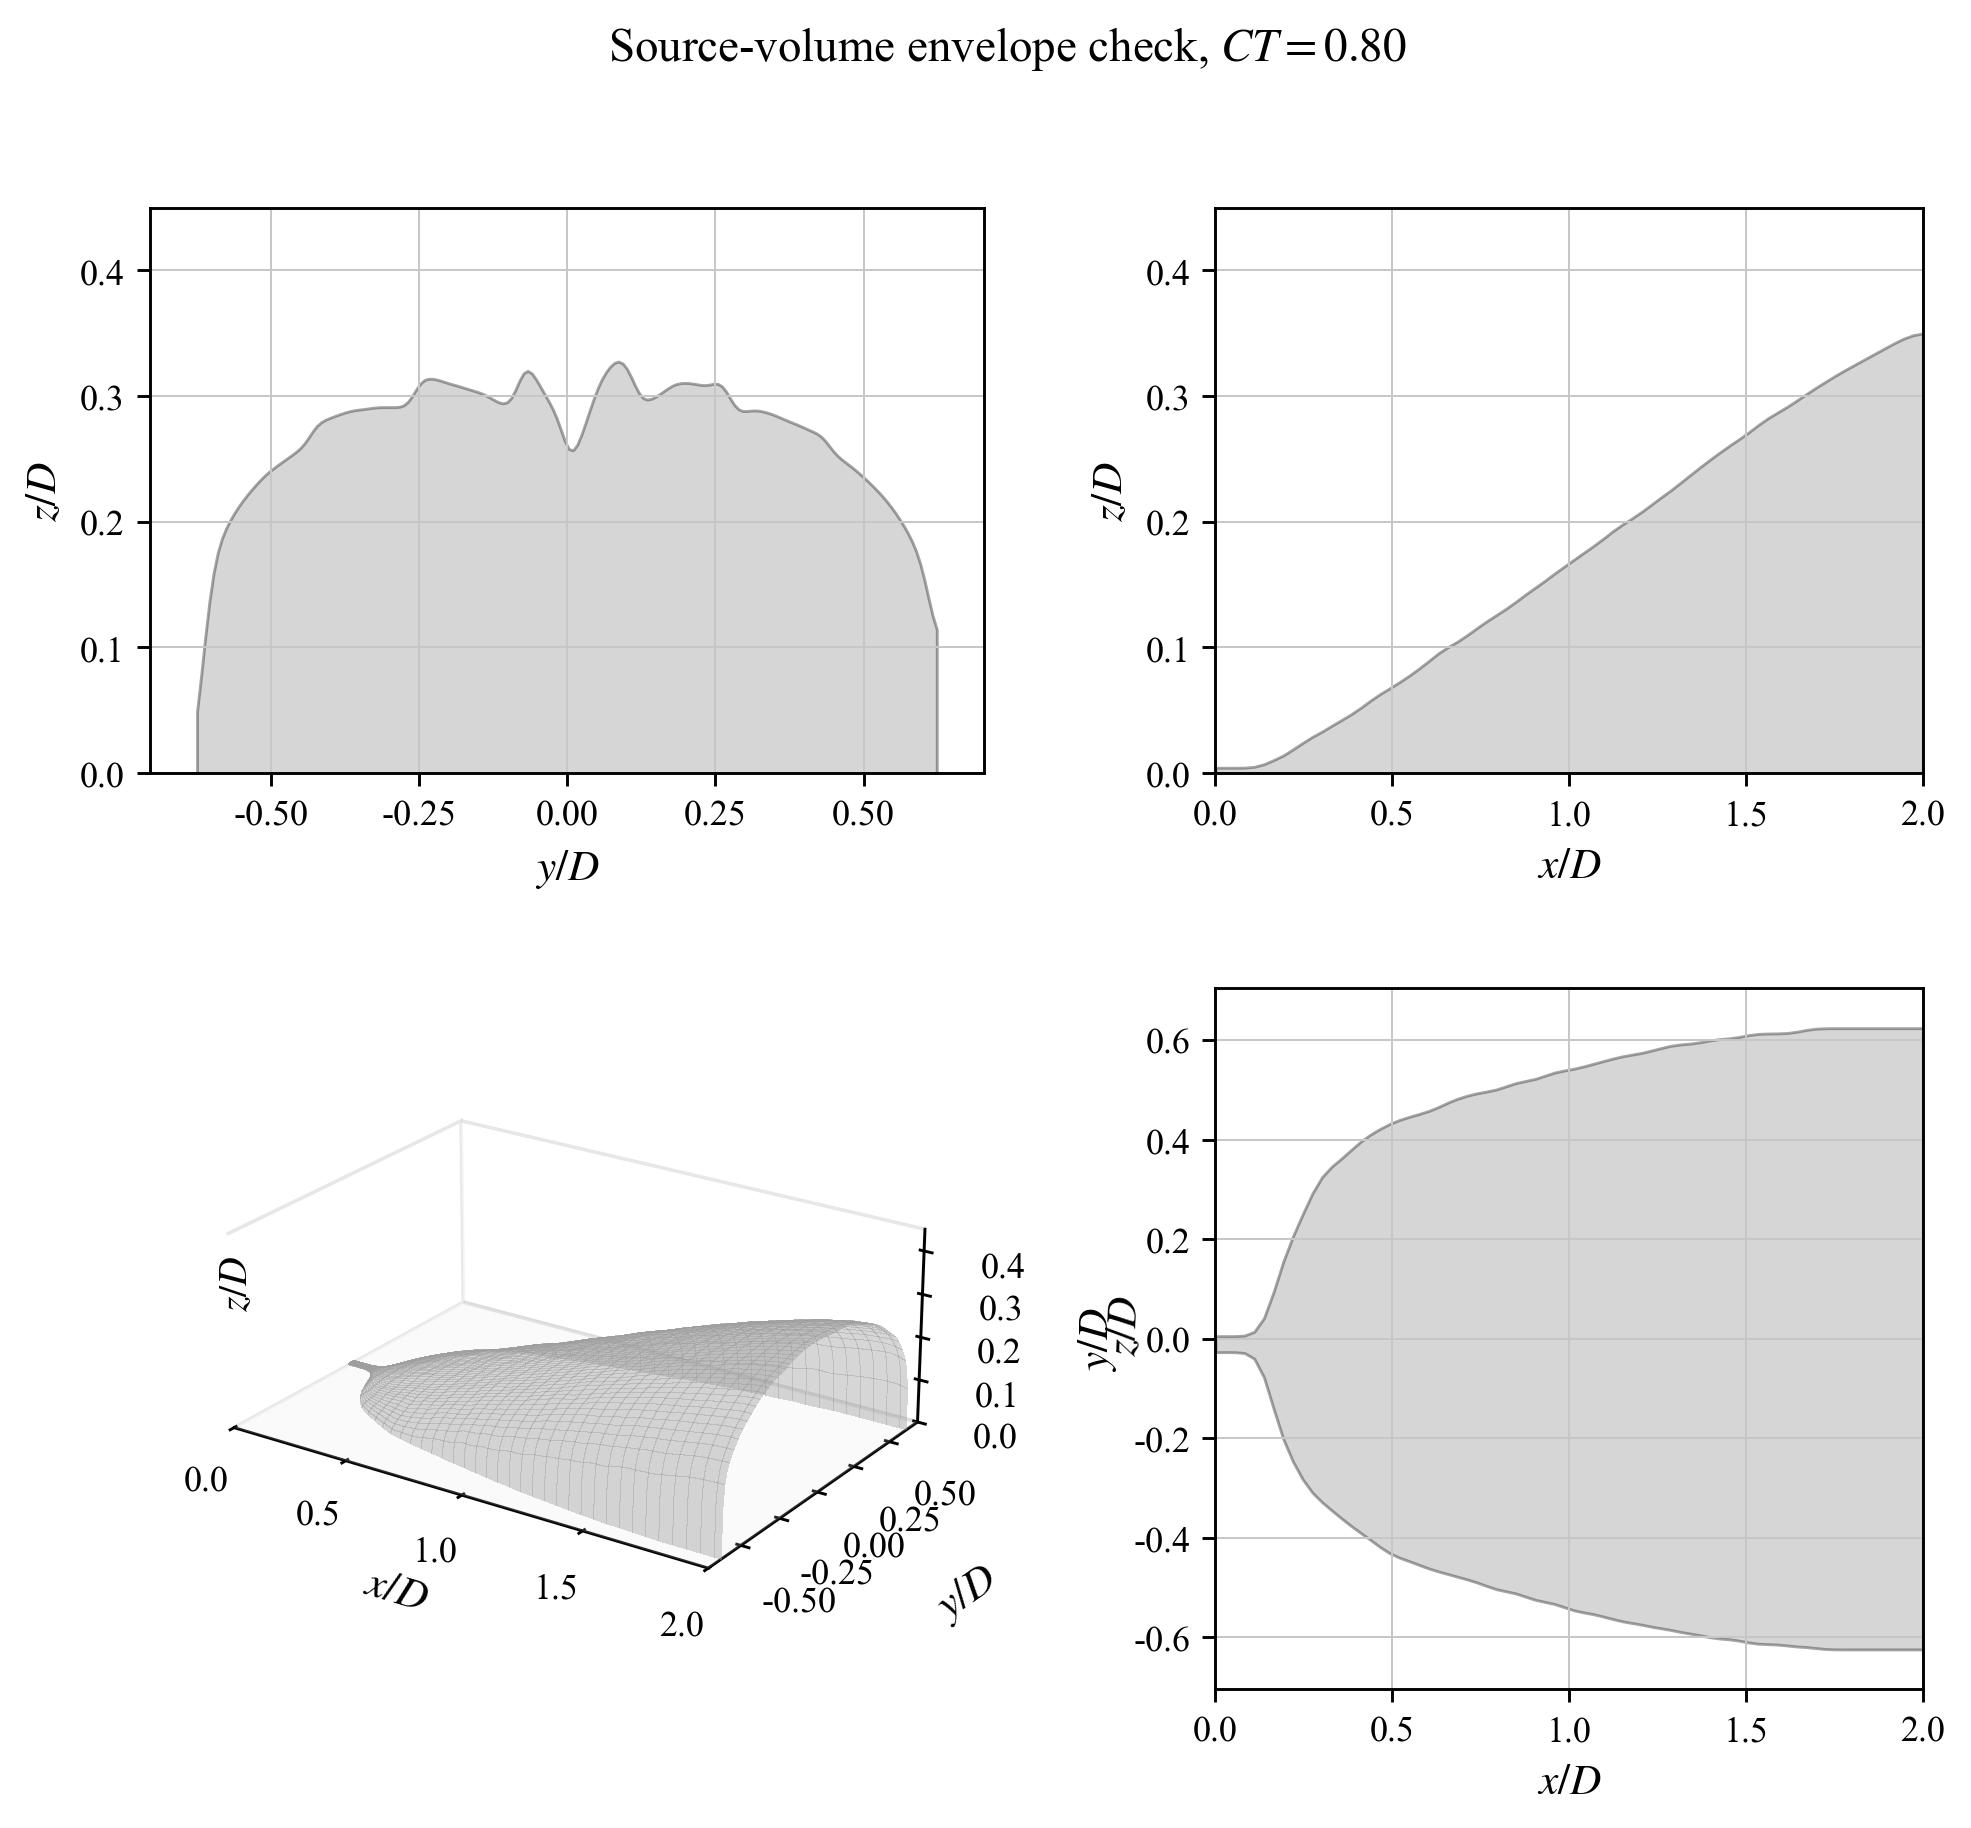

In [7]:
# Purpose: run the complete CT envelope workflow and display concise outputs.
csv_path = choose_csv(CSV_PATH)
print(f"Loading data from {csv_path.name} ...")
df, refs = load_cfd_csv(csv_path)

print("Building CT=0.8 source-volume envelope ...")
x, y, z, valid_counts = extract_ct_envelope(df)
verts, faces = make_vertices_and_faces(x, y, z)
ratio = idw_surface_temperature_ratio(verts, df, refs["T_m"])

print("Rendering figures ...")
main_png = plot_main_envelope(x, y, z, verts, faces, ratio)
views_png = plot_reference_views(x, y, z, verts, faces)
diagnostics_png = plot_diagnostics(df, x, y, z)

summary = summarize_input(df, refs, csv_path)
summary["valid slice min points"] = int(valid_counts.min())
summary["valid slice max points"] = int(valid_counts.max())
summary["envelope max z/D"] = float(z.max())
summary["envelope y/D min"] = float(y.min())
summary["envelope y/D max"] = float(y.max())
summary["T/T_m min on surface"] = float(ratio.min())
summary["T/T_m max on surface"] = float(ratio.max())

print("Preview rows:")
display(df.head(5))
print("Summary:")
display(summary.T.rename(columns={0: "value"}))
print(f"Diagnostics: {diagnostics_png}")
display(Image(filename=diagnostics_png))
print(f"3D envelope: {main_png}")
display(Image(filename=main_png))
print(f"Four-view check: {views_png}")
display(Image(filename=views_png))
